In [8]:
import sys
sys.path.append('../src')
from clean_data import clean_chess
import pandas as pd
chess = pd.read_csv('../data/raw/chess_games.csv')
player=pd.read_csv('../data/raw/player_registry.csv')
chess = clean_chess(chess)

In [ ]:
merged = pd.merge(
    chess,
    player.rename(columns={'username':'white_id'}),
    on='white_id',
    how='left'
)

(20058, 29)

In [19]:
merged[merged['country'].isnull()].head()

,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,...,opening_family,is_suspicious,display_name,country,registered_year,rating_registry,total_games_registry,account_status,email_verified,join_platform
0,1,False,13,Out of Time,White,15+2,bourgris,1500,a-00,1191,...,Slav Defense,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,True,16,Resign,Black,5+10,a-00,1322,skinnerua,1261,...,Nimzowitsch Defense,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,True,61,Mate,White,5+10,ischia,1496,a-00,1500,...,King's Pawn Game,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,True,61,Mate,White,20+0,daniamurashov,1439,adivanov2009,1454,...,Queen's Pawn Game,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,True,95,Mate,White,30+3,nik221107,1523,adivanov2009,1469,...,Philidor Defense,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
merged[merged['country'].isnull()]['white_id'].nunique()

9251

Q16 — How many white players in the
chess data have no registry entry? Approximately 9,251 unique white players have no registry entry.

In [21]:
merged['country'].value_counts()

country
Spain                 513
Ukraine               330
Russia                274
Poland                269
Brazil                242
India                 214
BRA                   202
UA                    177
United Kingdom        160
united states         153
RUS                   149
united kingdom        134
Germany               134
France                133
USA                   124
DE                    104
poland                103
United States          99
Deutschland            97
france                 90
US                     80
PL                     73
GB                     63
IN                     59
FR                     57
ES                     57
brazil                 45
UK                     20
russian federation      4
Name: count, dtype: int64

In [26]:
country_map = {
    'US': 'United States',
    'USA': 'United States',
    'united states': 'United States',

    'GB': 'United Kingdom',
    'UK': 'United Kingdom',
    'united kingdom': 'United Kingdom',

    'RUS': 'Russia',
    'russian federation': 'Russia',

    'FR': 'France',
    'france': 'France',

    'DE': 'Germany',
    'Deutschland': 'Germany',

    'PL': 'Poland',
    'poland': 'Poland',

    'BRA': 'Brazil',
    'brazil': 'Brazil',

    'UA': 'Ukraine',

    'IN': 'India',

    'ES': 'Spain'
}
merged['country'] = merged['country'].map(country_map).fillna(merged['country']
)

Q17 — How many country name
inconsistencies exist (e.g.
'US'/'USA'/'United States')?
There are at least 10 country-name inconsistencies, including
US/USA/United States, GB/UK/United Kingdom,
Russia/RUS/russian federation, France/FR/france,
Germany/DE/Deutschland, Poland/PL/poland,
Brazil/BRA/brazil, Ukraine/UA, India/IN, and Spain/ES.

In [28]:
merged['winner'].value_counts()

winner
White    10001
Black     9107
Draw       950
Name: count, dtype: int64

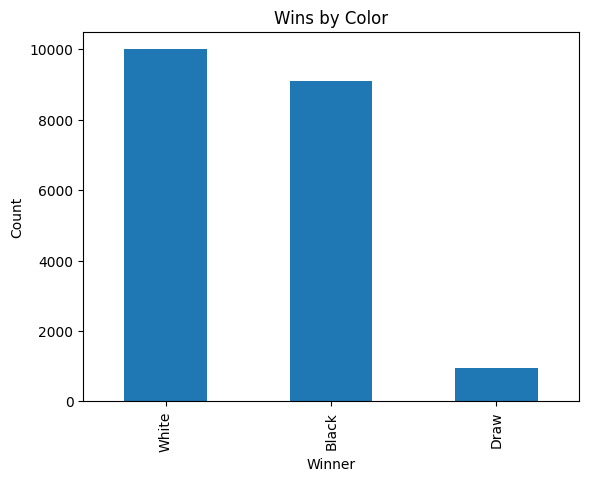

In [ ]:
import matplotlib.pyplot as plt

chess['winner'].value_counts().plot(kind='bar')

plt.title('Wins by Color')
plt.xlabel('Winner')
plt.ylabel('Count')

plt.savefig('../output/plots/wins_by_color.png')
plt.show()

Q18 — Plot: bar chart of win counts by
color. Save to output/wins_by_color.png
→ White: 10001 Black: 9107 Draw: 950

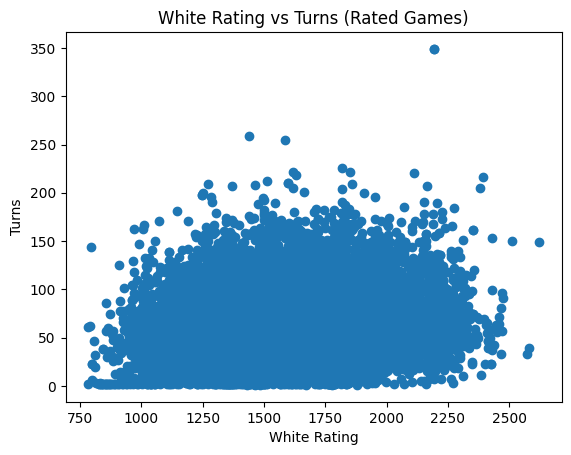

In [ ]:
rated_games = chess[chess['rated'] == True]

import matplotlib.pyplot as plt

plt.scatter(
    rated_games['white_rating'],
    rated_games['turns']
)

plt.xlabel('White Rating')
plt.ylabel('Turns')
plt.title('White Rating vs Turns (Rated Games)')
plt.savefig('../output/plots/white_rating_vs_turns.png')

plt.show()

Q19 — Plot: scatter of white_rating vs
turns for rated games. What do you
observe?
Higher-rated games not necessarily longer